# Comparación de LDA y QDA - Wine Dataset

Andres Velez - Ciencia de Datos e IA - Aprendizaje Automático

Taller de análisis discriminante lineal y cuadrático usando el Wine Dataset.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report


## 1. Descripción del dataset

Uso el Wine Dataset que viene con sklearn, sin modificarlo.

- Son 178 vinos de 3 cultivares distintos de uva (de la misma zona de Italia).
- Tiene 13 variables numéricas que salen de análisis químicos (alcohol, magnesio, flavonoides, etc).
- La variable a predecir es el cultivar (target), que tiene 3 clases.


In [2]:
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target
df["cultivar"] = df["target"].map(dict(enumerate(wine.target_names)))

print(df.shape)
df.head()


(178, 15)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


## 2. Exploración de los datos

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [4]:
df.isnull().sum()


alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
cultivar                        0
dtype: int64

In [5]:
df[wine.feature_names].describe().T


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [6]:
df["cultivar"].value_counts()


cultivar
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

No hay valores nulos y las 3 clases están más o menos balanceadas (59, 71 y 48 vinos aprox).

## 3. Visualización

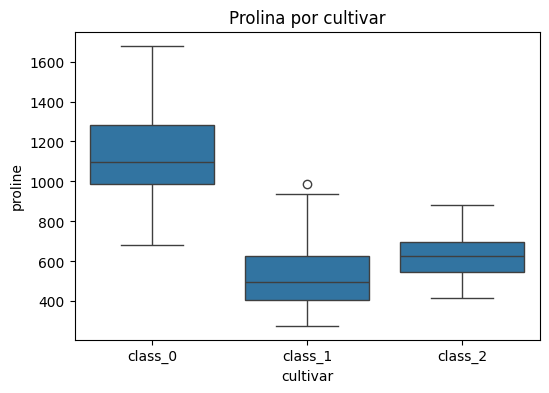

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="cultivar", y="proline")
plt.title("Prolina por cultivar")
plt.show()


Se ve que la prolina cambia bastante entre cultivares, sobre todo el cultivar 0 tiene valores más altos.

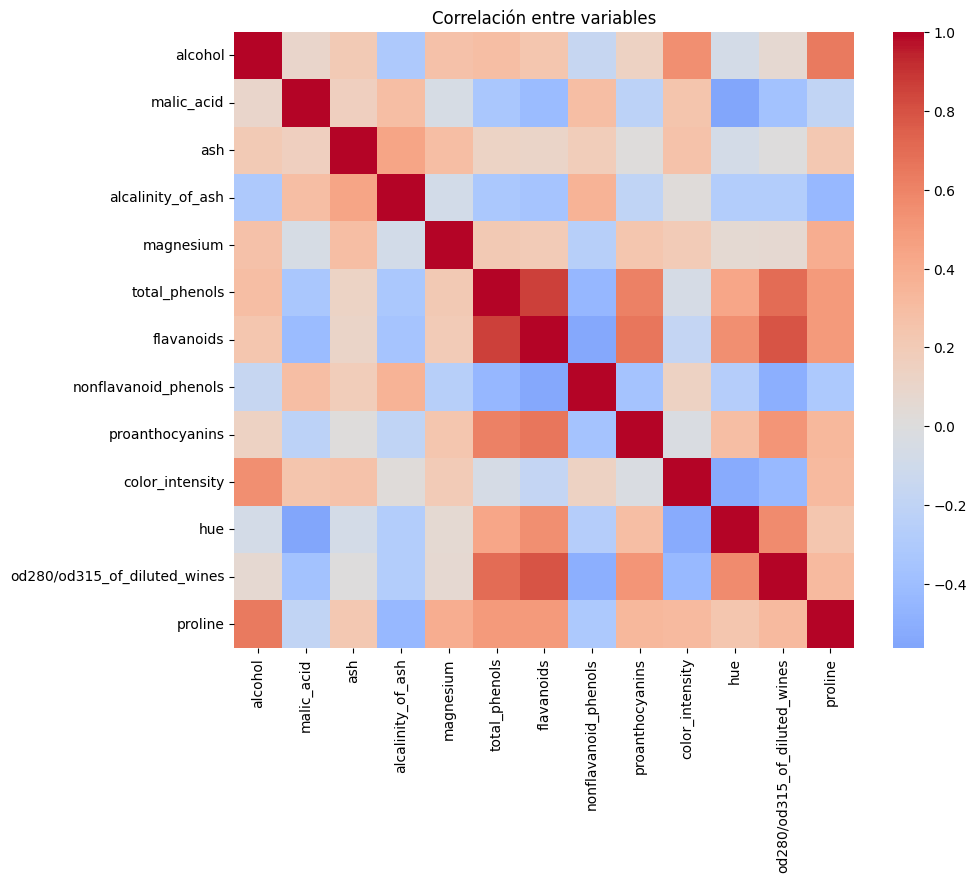

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df[wine.feature_names].corr(), cmap="coolwarm", center=0)
plt.title("Correlación entre variables")
plt.show()


Flavonoides y fenoles totales están bastante correlacionados. Eso puede afectar un poco a la matriz de covarianza que usan LDA y QDA.

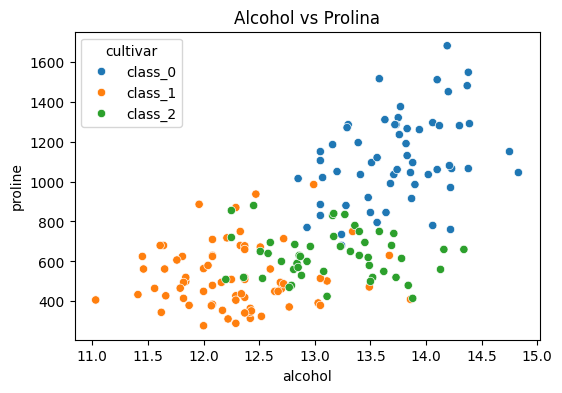

In [9]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="alcohol", y="proline", hue="cultivar")
plt.title("Alcohol vs Prolina")
plt.show()


Con estas dos variables ya se ven los 3 grupos bastante separados, eso es buena señal para los modelos.

## 4. Preparación de los datos

Separo en train/test (75/25) y estandarizo con StandardScaler porque las variables tienen escalas muy distintas (por ejemplo proline llega a cientos y hue está entre 0 y 2). No hago nada más porque el taller pide usar el dataset sin tratamiento.


In [10]:
X = df[wine.feature_names].values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train.shape, X_test.shape


((133, 13), (45, 13))

## 5. LDA

Uso LinearDiscriminantAnalysis con los parámetros por defecto (solver svd).


In [11]:
t0 = time.time()
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
t_lda = time.time() - t0

y_pred_lda = lda.predict(X_test)

acc_lda = accuracy_score(y_test, y_pred_lda)
prec_lda = precision_score(y_test, y_pred_lda, average="macro")
rec_lda = recall_score(y_test, y_pred_lda, average="macro")
f1_lda = f1_score(y_test, y_pred_lda, average="macro")

print("accuracy:", acc_lda)
print("precision:", prec_lda)
print("recall:", rec_lda)
print("f1:", f1_lda)


accuracy: 0.9555555555555556
precision: 0.9606481481481483
recall: 0.9537037037037037
f1: 0.95623603968625


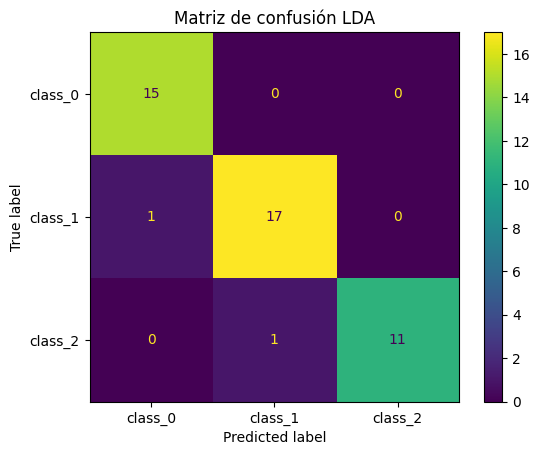

In [12]:
cm_lda = confusion_matrix(y_test, y_pred_lda)
ConfusionMatrixDisplay(cm_lda, display_labels=wine.target_names).plot()
plt.title("Matriz de confusión LDA")
plt.show()


LDA falla en 2 de los 45 vinos de prueba (accuracy 0.9556), los errores son con la clase 1.

## 6. QDA

Ahora uso QuadraticDiscriminantAnalysis, también con parámetros por defecto.


In [13]:
t0 = time.time()
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
t_qda = time.time() - t0

y_pred_qda = qda.predict(X_test)

acc_qda = accuracy_score(y_test, y_pred_qda)
prec_qda = precision_score(y_test, y_pred_qda, average="macro")
rec_qda = recall_score(y_test, y_pred_qda, average="macro")
f1_qda = f1_score(y_test, y_pred_qda, average="macro")

print("accuracy:", acc_qda)
print("precision:", prec_qda)
print("recall:", rec_qda)
print("f1:", f1_qda)


accuracy: 1.0
precision: 1.0
recall: 1.0
f1: 1.0


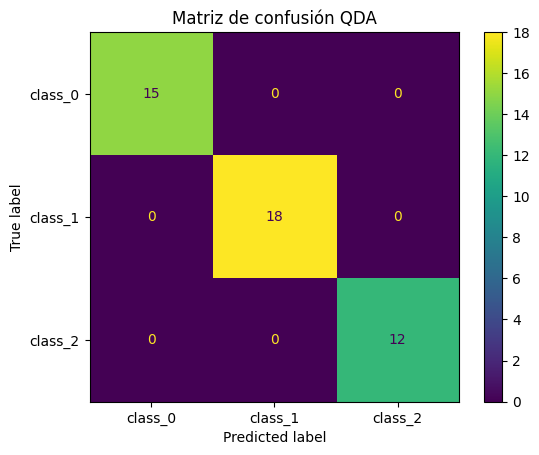

In [14]:
cm_qda = confusion_matrix(y_test, y_pred_qda)
ConfusionMatrixDisplay(cm_qda, display_labels=wine.target_names).plot()
plt.title("Matriz de confusión QDA")
plt.show()


QDA clasifica bien los 45 vinos de prueba (accuracy 1.0), no tiene ningún error.

## 7. Comparación

Junto las métricas de los dos modelos en una tabla.


In [15]:
pd.DataFrame({
    "metrica": ["accuracy", "precision", "recall", "f1", "tiempo entrenamiento"],
    "LDA": [acc_lda, prec_lda, rec_lda, f1_lda, t_lda],
    "QDA": [acc_qda, prec_qda, rec_qda, f1_qda, t_qda],
})


,metrica,LDA,QDA
0,accuracy,0.955556,1.000000
1,precision,0.960648,1.000000
2,recall,0.953704,1.000000
3,f1,0.956236,1.000000
4,tiempo entrenamiento,0.005278,0.004087


QDA le gana a LDA en este dataset (100% vs 95.6% de accuracy). Esto quiere decir que las 3 clases no tienen exactamente la misma covarianza, entonces dejar que QDA estime una covarianza por clase ayuda. LDA sigue siendo más simple y rápido de entrenar, pero acá QDA da mejor resultado. Con menos datos por clase probablemente LDA sería más seguro, porque QDA necesita estimar más parámetros (una matriz de covarianza completa por cada clase).

## 8. Frontera de decisión

Entreno de nuevo LDA y QDA pero solo con 2 variables (alcohol y prolina) para poder graficar la frontera.


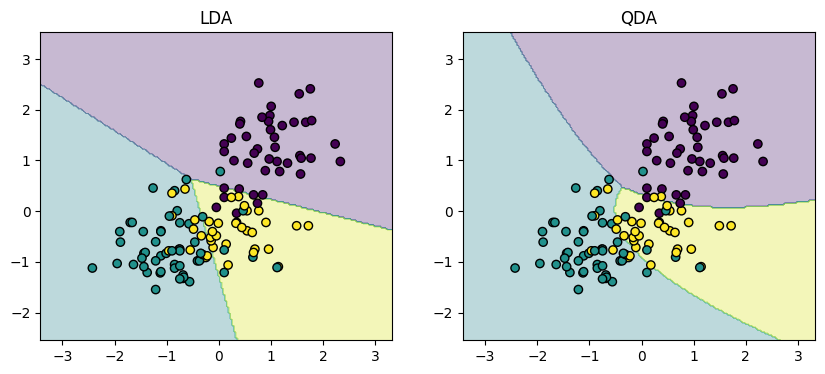

In [16]:
fx, fy = "alcohol", "proline"
ix, iy = wine.feature_names.index(fx), wine.feature_names.index(fy)

X2 = X_train[:, [ix, iy]]

lda2 = LinearDiscriminantAnalysis().fit(X2, y_train)
qda2 = QuadraticDiscriminantAnalysis().fit(X2, y_train)

xx, yy = np.meshgrid(np.linspace(X2[:,0].min()-1, X2[:,0].max()+1, 200),
                      np.linspace(X2[:,1].min()-1, X2[:,1].max()+1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].contourf(xx, yy, lda2.predict(grid).reshape(xx.shape), alpha=0.3)
ax[0].scatter(X2[:,0], X2[:,1], c=y_train, edgecolor="k")
ax[0].set_title("LDA")
ax[1].contourf(xx, yy, qda2.predict(grid).reshape(xx.shape), alpha=0.3)
ax[1].scatter(X2[:,0], X2[:,1], c=y_train, edgecolor="k")
ax[1].set_title("QDA")
plt.show()


Se nota bien la diferencia: LDA separa las clases con líneas rectas, QDA con curvas. Eso es porque QDA no asume que todas las clases tienen la misma covarianza.

## 9. Conclusiones

1. LDA separa las clases con fronteras rectas y le fue bien igual (95.6% de accuracy), aunque tuvo 2 errores con la clase 1.
2. QDA usa fronteras curvas porque cada clase tiene su propia covarianza, y en este caso clasificó todo bien (100%).
3. Que QDA gane sugiere que las covarianzas de las 3 clases no son iguales entre ellas.
4. En tiempo de entrenamiento casi no hay diferencia entre los dos, es un dataset chico.
5. Para este dataset conviene más QDA, pero si hubiera menos datos por clase probablemente LDA sería más confiable porque QDA necesita estimar más parámetros.
